# Segmentation and Fudging

In [1]:
import os

# Set environment variables to disable multithreading as users
# will probably
# want to set the number of cores to the max of their computer.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
#########################################################################
# Set TensorFlow print of log information
# 0 = all messages are logged (default behavior)
# 1 = INFO messages are not printed
# 2 = INFO and WARNING messages are not printed
# 3 = INFO, WARNING, and ERROR messages are not printed
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys

from anomaly.constants import GALAXY_LINES

from astroExplain.spectra.fudge import Fudge
from astroExplain.spectra.notebook import neighbors_explainer
from astroExplain.spectra.segment import SpectraSegmentation
from astroExplain.spectra.neighbors import SpectraNeighbors
from astroExplain.spectra.notebook import spectrum_in_segments

from autoencoders.ae import AutoEncoder
from anomaly.utils import specobjid_to_idx

from sdss.metadata import MetaData
from sdss.utils.managefiles import FileDirectory

meta = MetaData()


# Custom functions

## Figures

### Neigbors

In [13]:
def plot_neighbor(
    wave,
    spectrum,
    neighbor,
    neighbor_reconstruction,
    figsize: tuple = (10, 9),
):

    fig, axs = plt.subplots(
        nrows=2, ncols=1, figsize=figsize, tight_layout=True
    )

    axs[0].plot(wave, spectrum, color="black", label="original")
    axs[0].plot(wave, neighbor, color="red", alpha=0.5, label="perturbation")
    axs[0].set_ylabel("Normalized flux")

    axs[1].plot(wave, spectrum, color="black", alpha=1, label="original")
    axs[1].plot(
        wave,
        neighbor_reconstruction,
        color="red",
        alpha=0.5,
        label="reconstruction of perturbation",
    )

    axs[1].set_ylabel("flux")
    axs[1].set_xlabel(r"\lambda$ [nm]")

    for ax in axs:
        ax.legend()

    return fig, axs


### Segmentation

In [22]:
def segment_spec(
    wave: np.array,
    spectrum: np.array,
    segmentation: np.array,
    number_segments: int = 100,
):

    segmenter = SpectraSegmentation()

    if segmentation == "uniform":

        segmentation_function = segmenter.uniform
        segmentation = "Uniform segmentation with"

    elif segmentation == "kmeans":

        segmentation_function = segmenter.kmeans
        segmentation = "SLIC segmentation with"

    else:
        print(f"Segmenation {segmentation} not defined")
        sys.exit()

    segments = segmentation_function(spectrum, number_segments=number_segments)
    segmented_spectrum = spectrum_in_segments(spectrum, segments)

    number_segments = np.unique(segments).size
    print(f"Number of segments: {number_segments}")

    return segments, segmented_spectrum

# Config

## Directories

In [9]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
ch_5_dir = f"{thesis_dir}/chapters/05_figures"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
latent_dir = f"{data_dir}/latent"
explanations_dir = f"{data_dir}/explanations"
bins_ids = [f'bin_{i:02d}' for i in range(4)] 

## Data

In [ ]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave*0.1
n_wave = wave.shape

spectra = np.load(
    f"{spectra_dir}/spectra_imputed.npy",
    mmap_mode="r"
)

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(
    f"{spectra_dir}/ids_imputing.npy",
    mmap_mode='r'
)

## Scores

### Residulas

In [8]:
bin_id = 'bin_03'
score_df = pd.read_csv(
    f"{scores_dir}/{bin_id}/scores_{bin_id}.csv.gz",
    index_col='specobjid'
)

rank = np.arange(score_df.shape[0]) + 1
score_rank_df = score_df.copy()
# score_rank_df
for col in score_df.columns:

    index_sorted = score_df.sort_values(
        by=col, ascending=False
    ).index

    score_rank_df.loc[index_sorted, f'rank_{col}'] = rank
    score_rank_df[f'rank_{col}'].astype(int)

## Models

### VAE

In [5]:
bin_id = 'bin_03'
ae_model = AutoEncoder(
    reload=True,
    reload_from=f"{models_dir}/{bin_id}/winner",
)

# Segmentation

## Uniform

Number of segments: 111


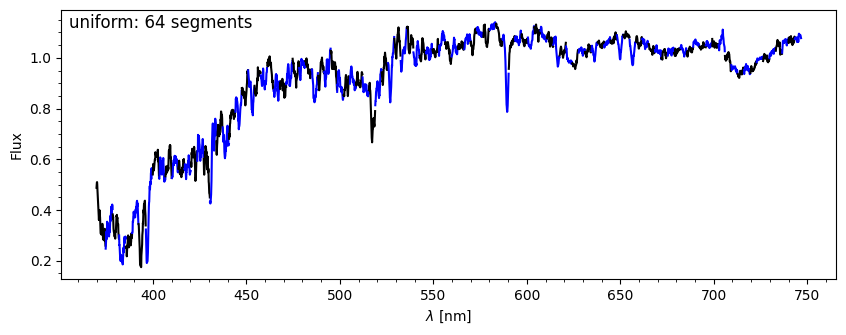

In [46]:
n_spec = score_rank_df.shape[0]
normal_mask = score_rank_df['rank_mse'] == n_spec-1 

specobjid = score_rank_df.loc[normal_mask].index[0]
idx_spec = specobjid_to_idx(specobjid, idx_id_spec)
spec = spectra[idx_spec]

segmentation = "uniform"
n_segments = 110

segments, segmented_spectrum = segment_spec(
    wave=wave_nm,
    spectrum=spec,
    segmentation=segmentation,
    number_segments=n_segments,
)

n_segments = np.unique(segments).size

fig, ax = plt.subplots(figsize=(10, 3.5))

for color_id, segment in zip(range(0, n_segments),segmented_spectrum):
    if color_id % 2 == 0:
        color = 'black'
    else:
        color = 'blue'

    ax.plot(wave_nm, segment, color=color)


ax.set_xlabel(r"$\lambda$ [nm]")
ax.set_ylabel("Flux")
ax.text(
    0.01, 0.95,
    f"{segmentation}: {number_segments} segments",
    horizontalalignment="left", verticalalignment="center",
    transform=ax.transAxes,
    fontsize=12
)

ax.minorticks_on()


## SLIC

Number of segments: 75


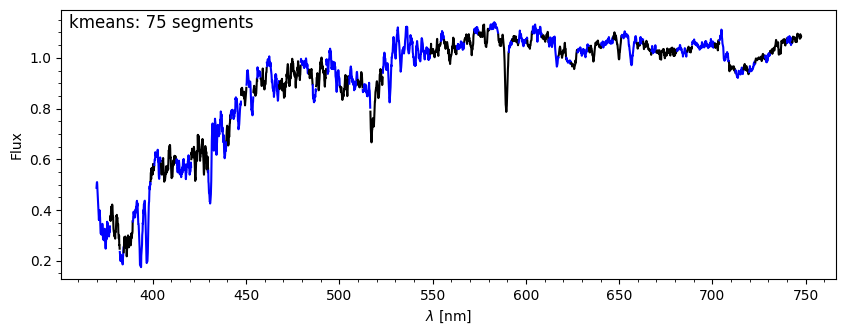

In [47]:
n_spec = score_rank_df.shape[0]
normal_mask = score_rank_df['rank_mse'] == n_spec-1 

specobjid = score_rank_df.loc[normal_mask].index[0]
idx_spec = specobjid_to_idx(specobjid, idx_id_spec)
spec = spectra[idx_spec]

segmentation = "kmeans"
n_segments = 110

segments, segmented_spectrum = segment_spec(
    wave=wave_nm,
    spectrum=spec,
    segmentation=segmentation,
    number_segments=n_segments,
)

n_segments = np.unique(segments).size

fig, ax = plt.subplots(figsize=(10, 3.5))

for color_id, segment in zip(range(0, n_segments),segmented_spectrum):
    if color_id % 2 == 0:
        color = 'black'
    else:
        color = 'blue'

    ax.plot(wave_nm, segment, color=color)


ax.set_xlabel(r"$\lambda$ [nm]")
ax.set_ylabel("Flux")
ax.text(
    0.01, 0.95,
    f"{segmentation}: {n_segments} segments",
    horizontalalignment="left", verticalalignment="center",
    transform=ax.transAxes,
    fontsize=12
)

ax.minorticks_on()


## Perturbation

### With mean

In [ ]:
fudge_parameters = {
    # same, same_shape, flat, with_mean, gaussians, scale
    "kind_of_fudge": "with_mean",
    # scale
    "scale_factor": 0.8,
    # flat
    "continuum": 1,
    # gaussians
    "amplitude": 0.2,
    "sigmas_in_segment": 8,
    # control-noise
    "same_noise": True,
    "kernel_size": 3,
    "sigma": 1,
}
segmentation = "kmeans"
# specobjid = 969534273977608192
# idx_spec = specobjid_to_idx(specobjid, idx_id)
# spectrum = spectra[idx_spec]
specobjid = normal_mse_df.index[0]
idx_spec = specobjid_to_idx(specobjid, idx_id)
spectrum = spectra[idx_spec]
# spectrum = spectra[idx_id[-2000, 0]]
number_segments = 64
neighbors = neighbors_explainer(
    number_samples=100,
    spectrum=spectrum,
    segmentation=segmentation,
    number_segments=number_segments,
    fudge_parameters=fudge_parameters,
)

Number of segments: 33


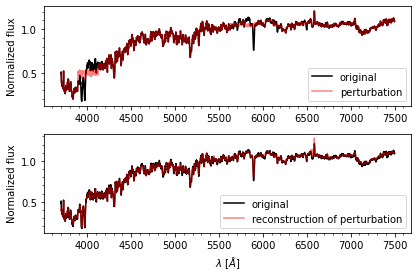

In [80]:
neighbor_id = 4
neighbor_reconstruction = model.reconstruct(neighbors[neighbor_id]).reshape(-1)

fig, axs = plot_neighbor(
    wave,
    spectrum=neighbors[0],
    neighbor=neighbors[neighbor_id],
    neighbor_reconstruction=neighbor_reconstruction,
    figsize=None,
)

for ax in axs:
    ax.minorticks_on()

save_to = "/home/edgar/explain-me-why/sections/figures/lime/fudging"

fname = (
    f"{segmentation}_{number_segments}_"
    f"fudge_{fudge_parameters['kind_of_fudge']}_"
    f"{specobjid}_{neighbor_id}"
)

fig.savefig(f"{save_to}/{fname}.pdf")

### Scale

In [ ]:
fudge_parameters = {
    # same, same_shape, flat, with_mean, gaussians, scale
    "kind_of_fudge": "scale",
    # scale
    "scale_factor": 0.8,
    # flat
    "continuum": 1,
    # gaussians
    "amplitude": 1.0,
    "sigmas_in_segment": 8,
    # control-noise
    "same_noise": True,
    "kernel_size": 3,
    "sigma": 1,
}
segmentation = "kmeans"
# specobjid = 969534273977608192
# idx_spec = specobjid_to_idx(specobjid, idx_id)
# spectrum = spectra[idx_spec]
specobjid = normal_mse_df.index[0]
idx_spec = specobjid_to_idx(specobjid, idx_id)
spectrum = spectra[idx_spec]
# spectrum = spectra[idx_id[-2000, 0]]
number_segments = 64
neighbors = neighbors_explainer(
    number_samples=100,
    spectrum=spectrum,
    segmentation=segmentation,
    number_segments=number_segments,
    fudge_parameters=fudge_parameters,
)
print(idx_spec)

Number of segments: 33
66456


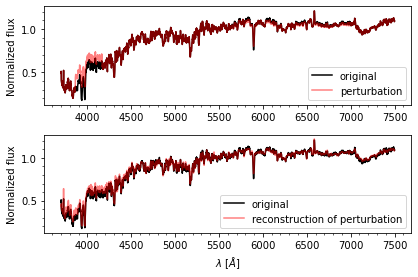

In [82]:
neighbor_id = 4
neighbor_reconstruction = model.reconstruct(neighbors[neighbor_id]).reshape(-1)

fig, axs = plot_neighbor(
    wave,
    spectrum=neighbors[0],
    neighbor=neighbors[neighbor_id],
    neighbor_reconstruction=neighbor_reconstruction,
    figsize=None,
)

for ax in axs:
    ax.minorticks_on()

save_to = "/home/edgar/explain-me-why/sections/figures/lime/fudging"

fname = (
    f"{segmentation}_{number_segments}_"
    f"fudge_{fudge_parameters['kind_of_fudge']}_"
    f"{specobjid}_{neighbor_id}"
)

fig.savefig(f"{save_to}/{fname}.pdf")

## Explore some anomalies

In [ ]:
fudge_parameters = {
    # same, same_shape, flat, with_mean, gaussians, scale
    "kind_of_fudge": "scale",
    # scale
    "scale_factor": 0.9,
    # flat
    "continuum": 1,
    # gaussians
    "amplitude": 100.0,
    "sigmas_in_segment": 2,
    # control-noise
    "same_noise": True,
    "kernel_size": 3,
    "sigma": 0.05,
}
idx_spec = specobjid_to_idx(531492683672217600, idx_id)
spectrum = spectra[idx_spec]

number_segments = 12

neighbors = neighbors_explainer(
    number_samples=100,
    spectrum=spectrum,
    segmentation="uniform",
    number_segments=number_segments,
    fudge_parameters=fudge_parameters,
)

Number of segments: 12


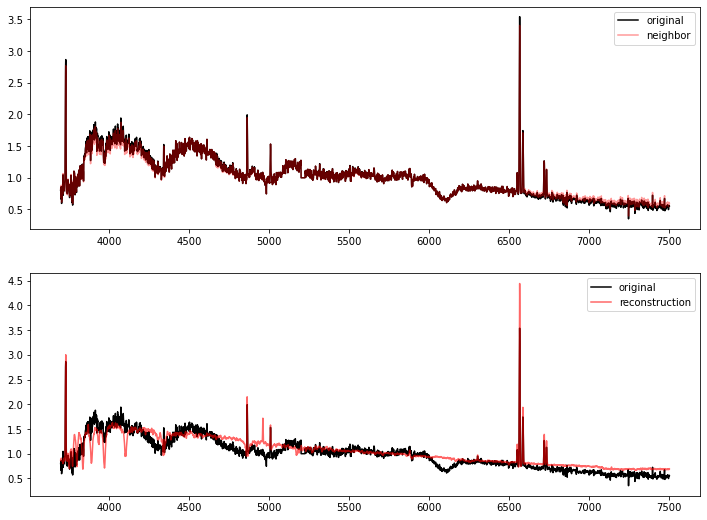

In [51]:
neighbor_id = 12
neighbor_reconstruction = model.reconstruct(neighbors[neighbor_id]).reshape(-1)
fig, axs = plot_neighbor(
    wave,
    spectrum=neighbors[0],
    neighbor=neighbors[neighbor_id],
    neighbor_reconstruction=neighbor_reconstruction,
    figsize=(12, 9),
)